In [21]:
import numpy as np 
import pandas as pd
import datetime as dt 
import yfinance as yf 
import matplotlib.pyplot as plt
from scipy.stats import norm 

Set a time from a certine number of years

In [15]:
years = 15

endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days= 365*years)

 Create a list of tickers 

In [4]:
tickers = ['SPY', 'BND', 'GLD', 'QQQ', 'VTI']

In [18]:
yf.download(tickers= 'SPY', start = startDate, end = endDate,  auto_adjust = True)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2011-09-30,87.137848,88.909095,87.076238,88.138986,288392300
2011-10-03,84.658089,87.753925,84.565673,86.629566,365136800
2011-10-04,86.514053,86.698884,82.732821,83.441320,459177500
2011-10-05,88.115868,88.346903,85.928761,86.729675,284108000
2011-10-06,89.710007,89.840930,87.415085,88.069676,257800800
...,...,...,...,...,...
2026-09-21,773.500000,774.890015,766.030029,766.250000,50484700
2026-09-22,773.380005,775.140015,772.570007,774.030029,34802300


Download the daily adjusted close prices for the tickers 

In [20]:
adj_close_df = pd.DataFrame()

for ticker in tickers: 
    data = yf.download(tickers= ticker, start = startDate, end = endDate, auto_adjust = True)
    adj_close_df[ticker] = data['Close']

print(adj_close_df)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                   SPY        BND         GLD         QQQ         VTI
Date                                                                 
2011-09-30   87.137848  54.278416  158.059998   46.137352   44.608074
2011-10-03   84.658089  54.586464  160.960007   44.950733   43.131954
2011-10-04   86.514053  54.371986  157.639999   45.873634   44.213917
2011-10-05   88.115868  54.138008  159.460007   47.051468   45.118141
2011-10-06   89.710007  54.105537  160.490005   47.842552   45.991432
...                ...        ...         ...         ...         ...
2026-09-21  773.500000  71.400002  398.380005  741.469971  380.140656
2026-09-22  773.380005  71.410004  400.070007  747.460022  380.310211
2026-09-23  767.809998  70.809998  392.880005  741.210022  377.277863
2026-09-24  767.179993  70.449997  391.690002  741.099976  377.128235
2026-09-25  771.349976  70.629997  393.410004  744.500000  378.813965

[3768 rows x 5 columns]


Log Returns

In [31]:
log_returns = np.log(adj_close_df/adj_close_df.shift(1))

log_returns.isna().sum()
log_returns =log_returns.dropna()

Expected Returns - function 

currently assuming that future return depends on past returns 

In [32]:
def expected_returns(weights, log_returns):
    return(np.sum(weights*log_returns.mean()))

Calculate portfolio Standard Deviation - funciton

In [53]:
def standard_deviation(weights, cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    return(np.sqrt(variance))

Covariance Matrix

In [37]:
cov_matrix = log_returns.cov()
print(cov_matrix)

          SPY       BND       GLD       QQQ       VTI
SPY  0.000111  0.000002  0.000010  0.000128  0.000113
BND  0.000002  0.000010  0.000009  0.000003  0.000003
GLD  0.000010  0.000009  0.000110  0.000013  0.000010
QQQ  0.000128  0.000003  0.000013  0.000169  0.000130
VTI  0.000113  0.000003  0.000010  0.000130  0.000116


Total return and standard deviation of equally weighted portfolio

In [55]:
portfolio_value = 100000
weights = np.array([1/len(tickers)]*len(tickers))
portfolio_expected_return = expected_returns(weights = weights, log_returns= log_returns )
portfolio_standard_dev = standard_deviation(weights, cov_matrix)

function that creates a random Z-score based on nornal distribution

In [57]:
def random_z_score():
    return np.random.normal(0, 1)

calculate scenario GainLoss

In [59]:
days = 5 

def scenraio_gain_loss(portfolio_value, portfolio_standard_dev, z_score, days):
    return portfolio_value * portfolio_expected_return * days + portfolio_value * portfolio_standard_dev * z_score * np.sqrt(days)

10,000 simulatins

In [61]:
simulations = 10000
scenarioReturn = []

for i in range(simulations):
    z_score = random_z_score()
    scenarioReturn.append(scenraio_gain_loss(portfolio_value, portfolio_standard_dev, z_score, days))

Specify confidence and calculate VaR

In [65]:
confidence_interval = 0.95
VaR = -np.percentile(scenarioReturn, 100*(1 - confidence_interval))
print(VaR)

2504.1761773663648


Plot histogram of results

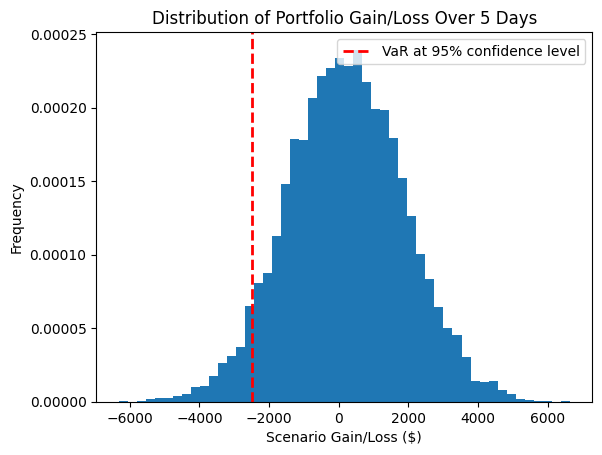

In [66]:
plt.hist(scenarioReturn, bins=50, density=True)
plt.xlabel('Scenario Gain/Loss ($)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio Gain/Loss Over {days} Days')
plt.axvline(
    -VaR,
    color='r',
    linestyle='dashed',
    linewidth=2,
    label=f'VaR at {confidence_interval:.0%} confidence level'
)
plt.legend()
plt.show()